In [29]:
import numpy as np
import math
import matplotlib.pyplot as plt
import scipy as sc
from collision import generate_spectrum, wigner_smith_matrix, wigner_smith_matrix_single, thermal_time_delay, relative_MB_weights

# parameters
e_mass = 5.48579909-4     # electron mass in amu
t0 = 315775               # a.u. to K
tau0 = 2.418884326509e-17 # a.u. to sec
 
#  universal truths, in SI units
kB = 1.3806e-23
hbar = 1.05457e-34
AMU = 1.6605e-27
Hartree = 4.359744e-18
auLength = 5.29177e-11

In [2]:
# define properties of molecules
reduced_masses = {"NaKNaK" : 62 / 2, "RbKRb" : 87 * (87 + 40) / (87 + 87 + 40)}     # amu
van_der_wall_coeffs = {"NaKNaK" : 561070, "RbKRb" : 8000}      # a.u.

molecules = "NaKNaK"
mu = reduced_masses[molecules] / e_mass      # now in a.u.
c6 = van_der_wall_coeffs[molecules]          # a.u.

# define natural units
beta = (2 * mu * c6) ** (1/4)    # length 
E_beta = 1 / (2 * mu * beta ** 2)   # energy
tau_beta = 2 * np.pi / E_beta    # time
print("beta (a0)", beta)
print("E_beta (K)", E_beta * t0)
print("tau_beta (s)", tau_beta * tau0)

abar = (np.pi * 2 ** (-3/2) / math.gamma(5/4) / math.gamma(1/2)) ** 2

beta (a0) 69.56041467855822
E_beta (K) 1.563946230456178
tau_beta (s) 3.068674998394627e-11


In [24]:
num_samples = 500

# properties of resonant spectrum
mean_spacing = 10.0
mean_x = 0.1
num_resonances = 400      # should be odd
mean_coupling_strength = np.sqrt(mean_x * mean_spacing / np.pi ** 2)

# thermal properties
threshold_energy = 0.1
temp = 0.5
num_energies = 2000

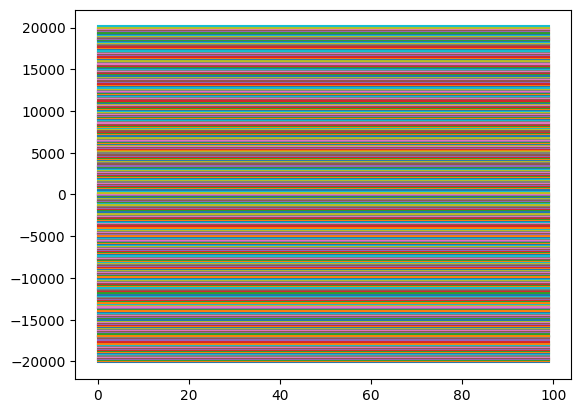

0.09999999999999996 0.09703724552177667


In [4]:
H_goe, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)

for i in range(num_resonances):
    plt.plot([j for j in range(100)], [H_goe[i] for j in range(100)])
# plt.ylim([-100, 100])
plt.show()

print(np.pi ** 2 / mean_spacing * mean_coupling_strength ** 2, x_actual)

In [25]:
energy_GOE_mat, W_mat, x_actual = generate_spectrum(num_resonances, mean_spacing, mean_coupling_strength)

In [26]:
import importlib
import collision
importlib.reload(collision)
wigner_smith_matrix_single(1, energy_GOE_mat, np.square(W_mat))

np.float64(-0.38616438205441644)

In [27]:
f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat))
time_delay_int = sc.integrate.quad(f, 0, 10 * temp)[0]
time_delay_int

4.959060478918415

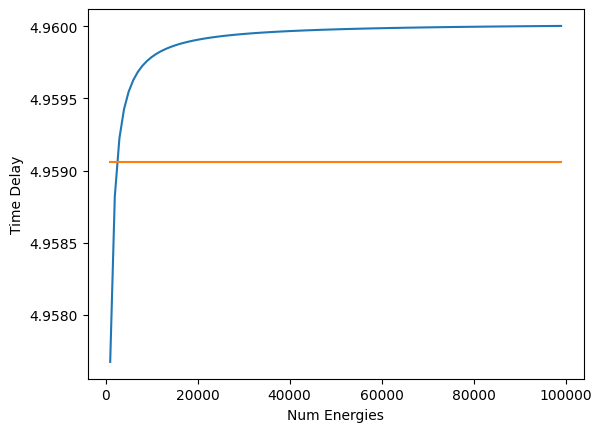

In [30]:
delays = []
num = []
for num_energies in range(1000, 100000, 1000):
    time_delay = thermal_time_delay(temp, energy_GOE_mat, W_mat, num_energies)
    num.append(num_energies)
    delays.append(time_delay)

plt.plot(num, delays)
plt.plot(num, [time_delay_int for i in num])
plt.xlabel("Num Energies")
plt.ylabel("Time Delay")
plt.savefig("convergence.pdf")
plt.show()

In [55]:
f = lambda energy : relative_MB_weights(temp, energy) * wigner_smith_matrix_single(energy, energy_GOE_mat, np.square(W_mat))
result = sc.integrate.quad(f, 0, 10 * temp)
result

(-0.781288788168723, 2.2809777786048855e-14)